# Time series modelling
## ARIMA models in R

This notebook draws on
- [ARIMA Models in R](https://app.datacamp.com/learn/courses/arima-models-in-r) (DataCamp)
- Hyndman, R.J. and Athanasopoulos, G. (2021) [*Forecasting: Principles and Practice*, 3rd edn](https://otexts.com/fpp3/). OTexts.
- Shumway, H. and Stoffer, S.D. (2011) [*Time Series Analysis and Its Applications*, 3rd edn](https://mybiostats.wordpress.com/wp-content/uploads/2015/03/time-series-analysis-and-its-applications-with-examples-in-r.pdf). Springer.

### Time series recap

Time series components
- trend
- seasonality
- cyclicality
- white noise

Weak (covariance) stationarity
- constant mean: $\mathbb{E}[X_t] = \mu$
- constant variance: $\text{Var}(X_t) = \sigma^2$
- autocovariance depends only on lag, not time: $\text{Cov}(X_t, X_{t-h}) = \gamma(h)$

#### Statistical models

AR(1) process

$$
X_t = \phi X_{t-1} + \epsilon_t, \quad \epsilon_t \sim WN
$$

MA(1) process

$$
\epsilon_t = W_t + \theta W_{t-1}, \quad W_t \sim WN
$$

ARMA(1,1) process

$$
X_t = \phi X_{t-1} + W_t + \theta W_{t-1}
$$

Random walk

$$
X_t = X_{t-1}+W_t, \quad W_t \sim WN
$$

We rebuild the basic statistical models from scratch [in our projects](https://github.com/tros01/projects/tree/main/exploring_statistics/time_series).

#### Transformations

Growth (return) rate $p_t$

$$\begin{align*}
X_t &= (1+p_t)X_{t-1} \\
Y_t &= \ln{(X_t)} - \ln{(X_{t-1})} \approx p_t
\end{align*}$$

* Percentage log returns: $(\ln{(X_t)} - \ln{(X_{t-1})}) * 100$.
* Logs stabilise variance.

#### Wold decomposition

In short, any stationary time series can be expressed as a linear combination of white noise. The maths of inverting processes is outlined [in our projects](https://github.com/tros01/projects/tree/main/exploring_statistics/time_series).

#### Exploratory data analysis

Workflow
1. Deflate the series if necessary.
2. Transform the data into returns or logs.
3. Visualis the ACF, PACF, CCF. Test for the unit root. Test for cointegration.
4. Detrend if no unit root is present. Difference if a unit root is present. Model multivariate series without a transformation if they cointegrate.

In [1]:
# Libraries
library(tidyverse)
library(astsa)
library(xts)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'astsa' was built under R version 4.5.3"
Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric



######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks la

### Helpers

In [15]:
# Set up Jupyter graph display
options(
  repr.plot.width = 10,
  repr.plot.height = 6,
  repr.plot.res = 150
)

In [ ]:
# List available datasets
data(package = .packages(all.available = TRUE))$results |>
    as_tibble() |>
    select(-LibPath) |>
    sample_n(5)

Package,Item,Title
<chr>,<chr>,<chr>
GGally,australia_PISA2012,Programme for International Student Assessment (PISA) 2012 Data for Australia
FinTS,d.c8603,"Financial time series for Tsay (2005, ch. 1)"
forcats,gss_cat,A sample of categorical variables from the General Social survey
datasets,esoph,"Smoking, Alcohol and (O)esophageal Cancer"
vcd,Bundesliga,Ergebnisse der Fussball-Bundesliga


In [ ]:
#help(AirPassengers)
#help(djia) # Stock data
#help(soi) # Southern oscillation index
#help(globtemp) # Global temperatures
#help(cmort) # Cardiovascular mortality in LA county

#### Coercing non-stationary series to stationarity

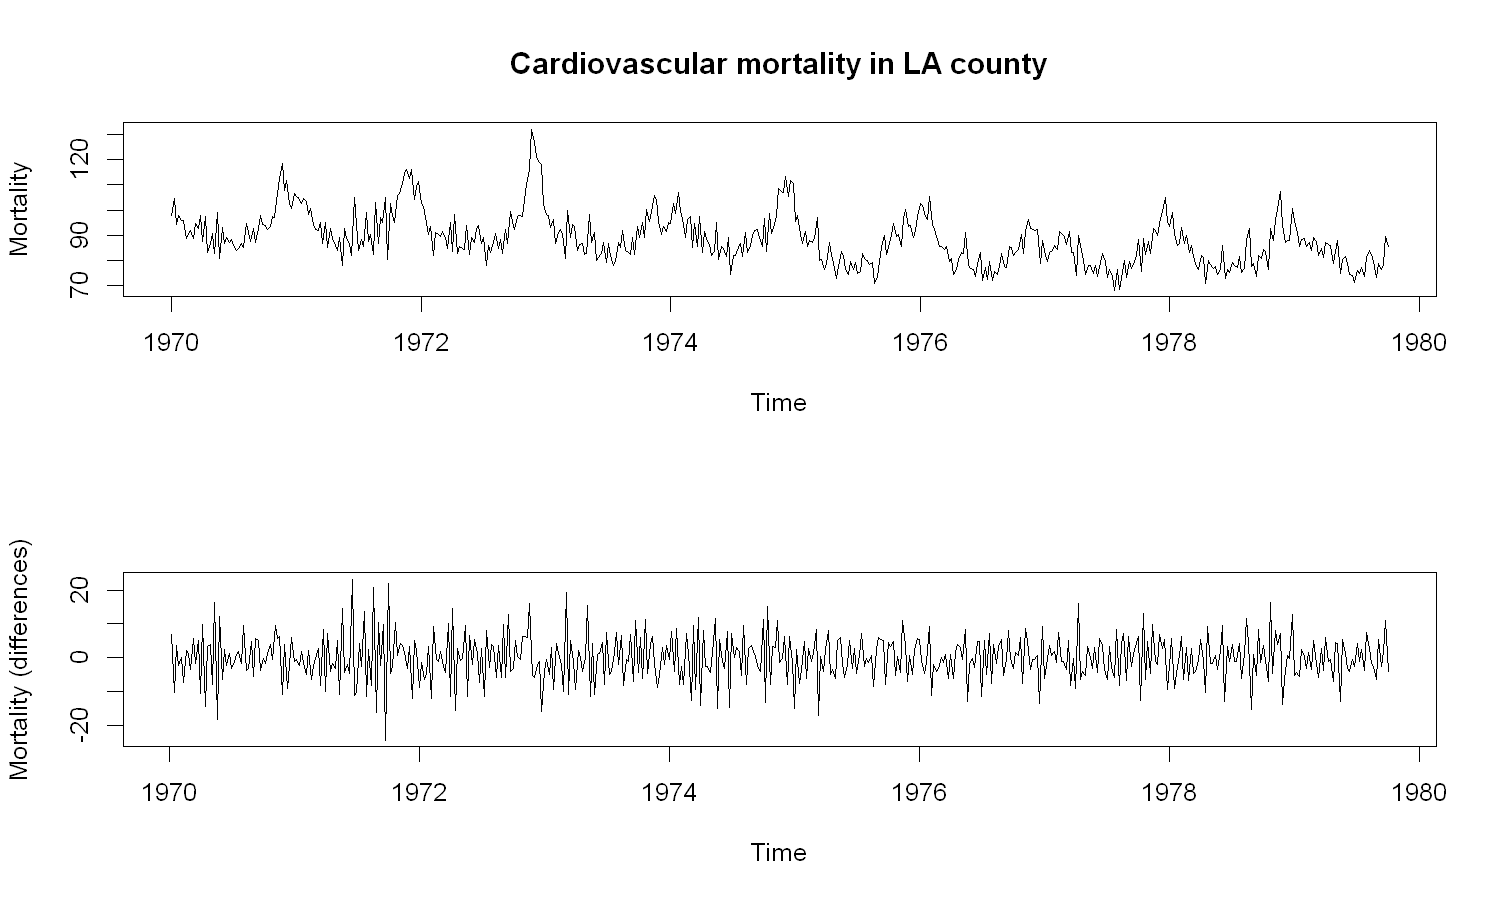

In [19]:
# Plot cmort and detrended cmort
par(mfrow = c(2,1))
plot(cmort, main = "Cardiovascular mortality in LA county", ylab = "Mortality")
plot(diff(cmort), ylab = "Mortality (differences)")

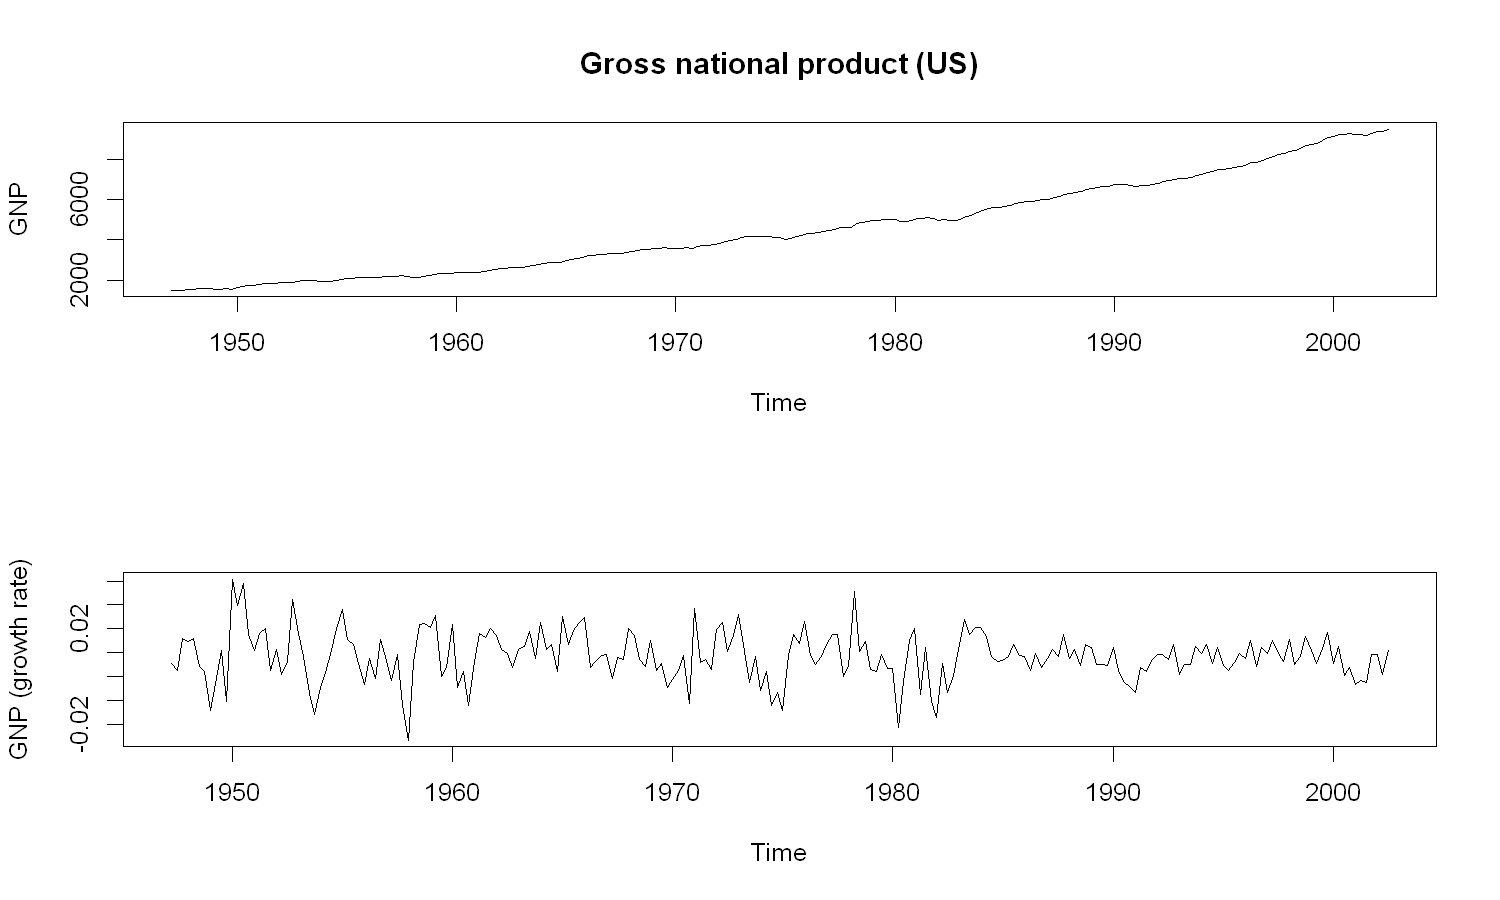

In [20]:
# Plot GNP series (gnp) and its growth rate
par(mfrow = c(2,1))
plot(gnp, main = "Gross national product (US)", ylab = "GNP")
plot(diff(log(gnp)), ylab = "GNP (growth rate)")

#### Simulating time series

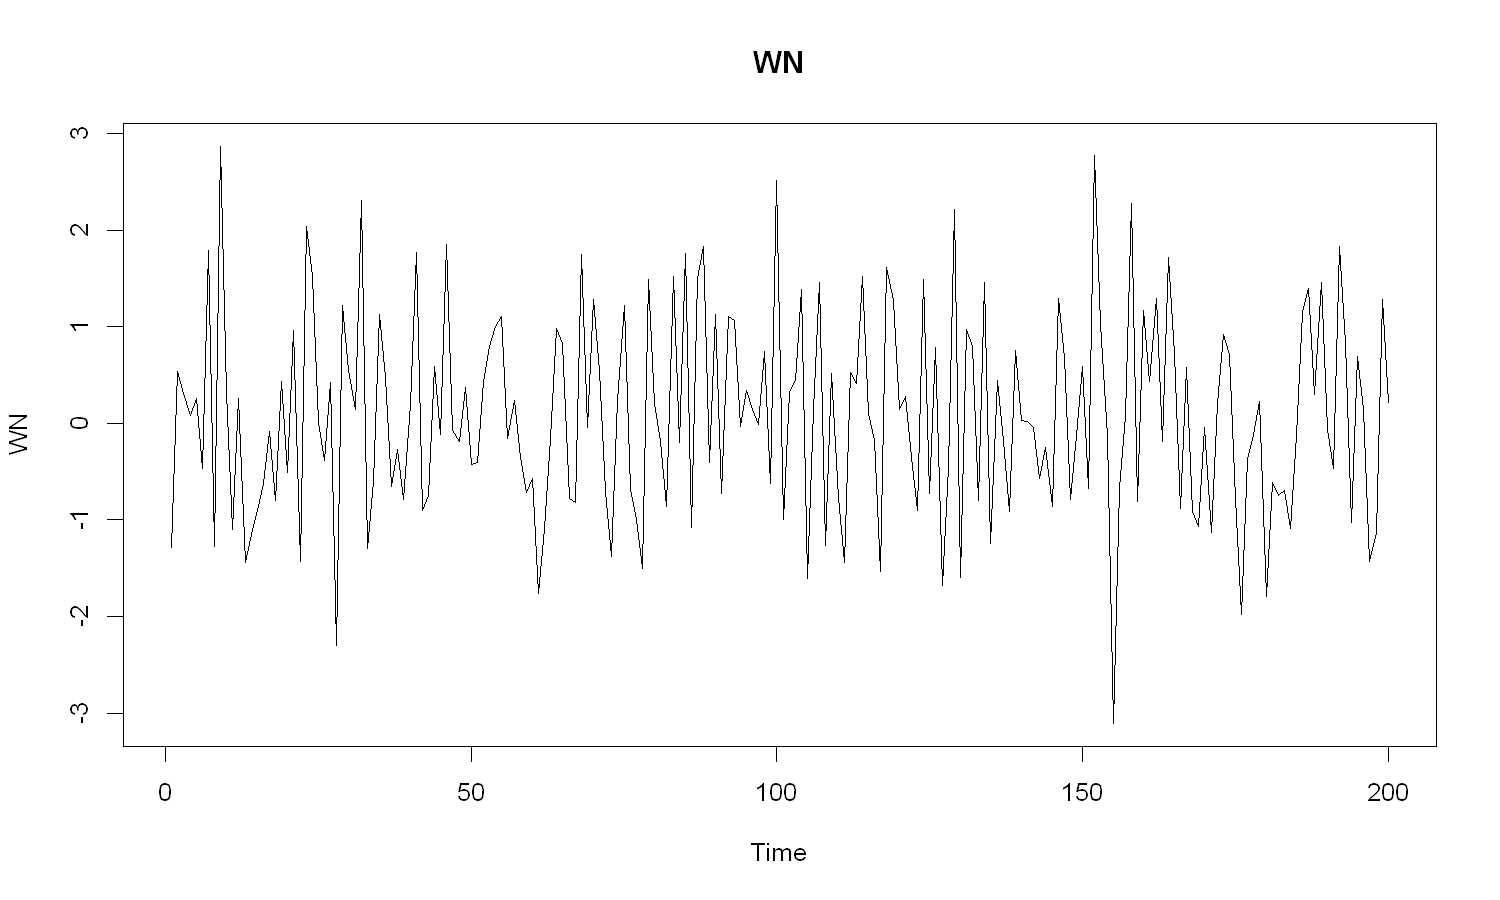

In [27]:
# Generate and plot white noise
WN <- arima.sim(model = list(order = c(0, 0, 0)), n = 200)
plot(WN, main = "WN")

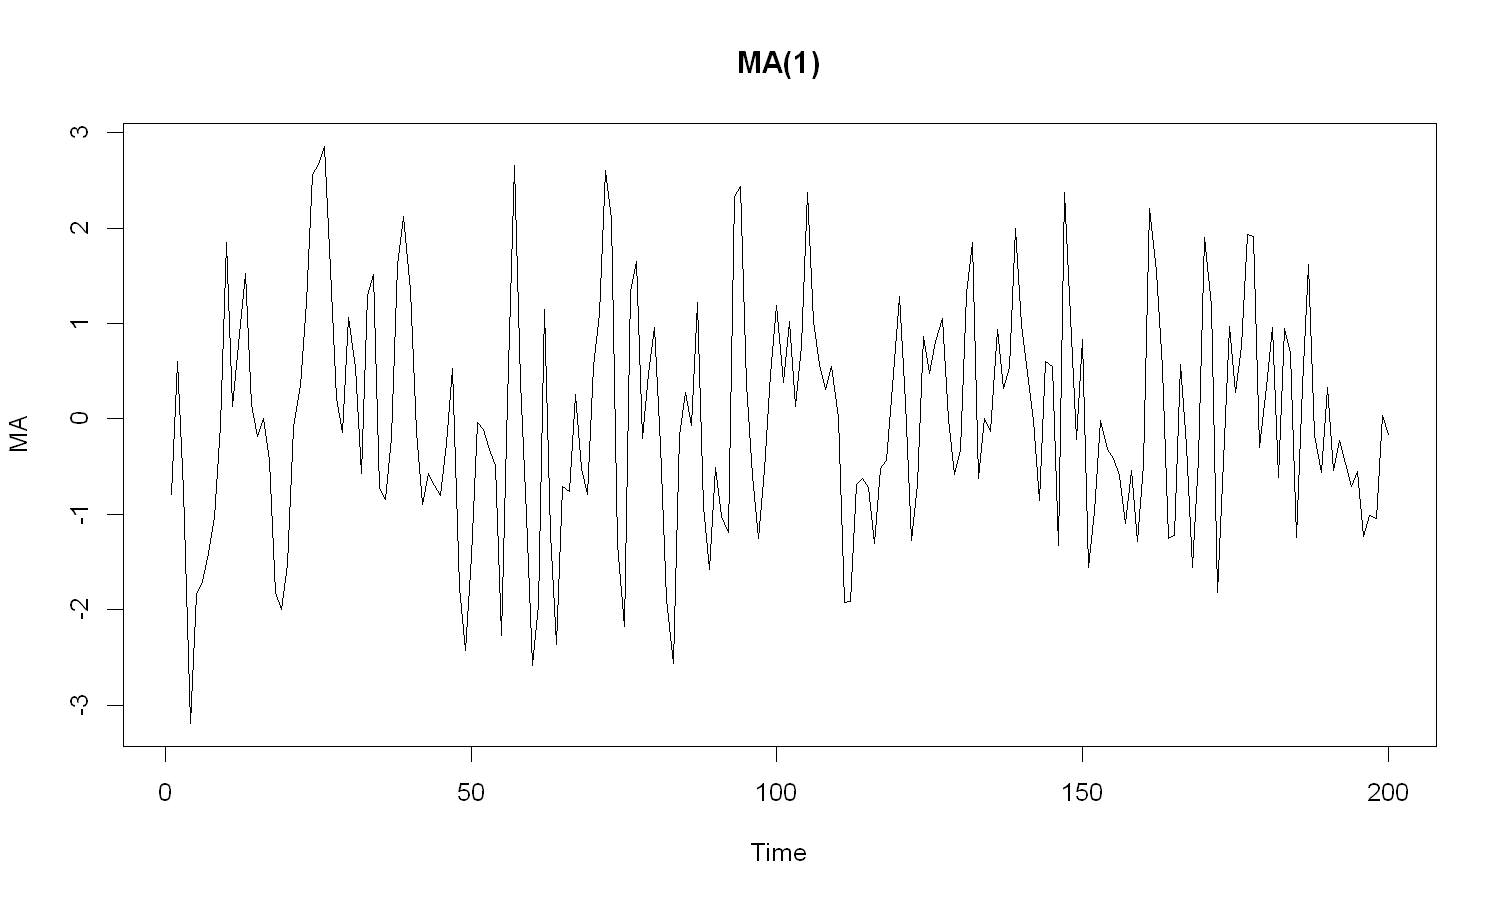

In [26]:
# Generate and plot an MA(1) with parameter .9 
MA <- arima.sim(model = list(order = c(0, 0, 1), ma = .9), n = 200)
plot(MA, main = "MA(1)")

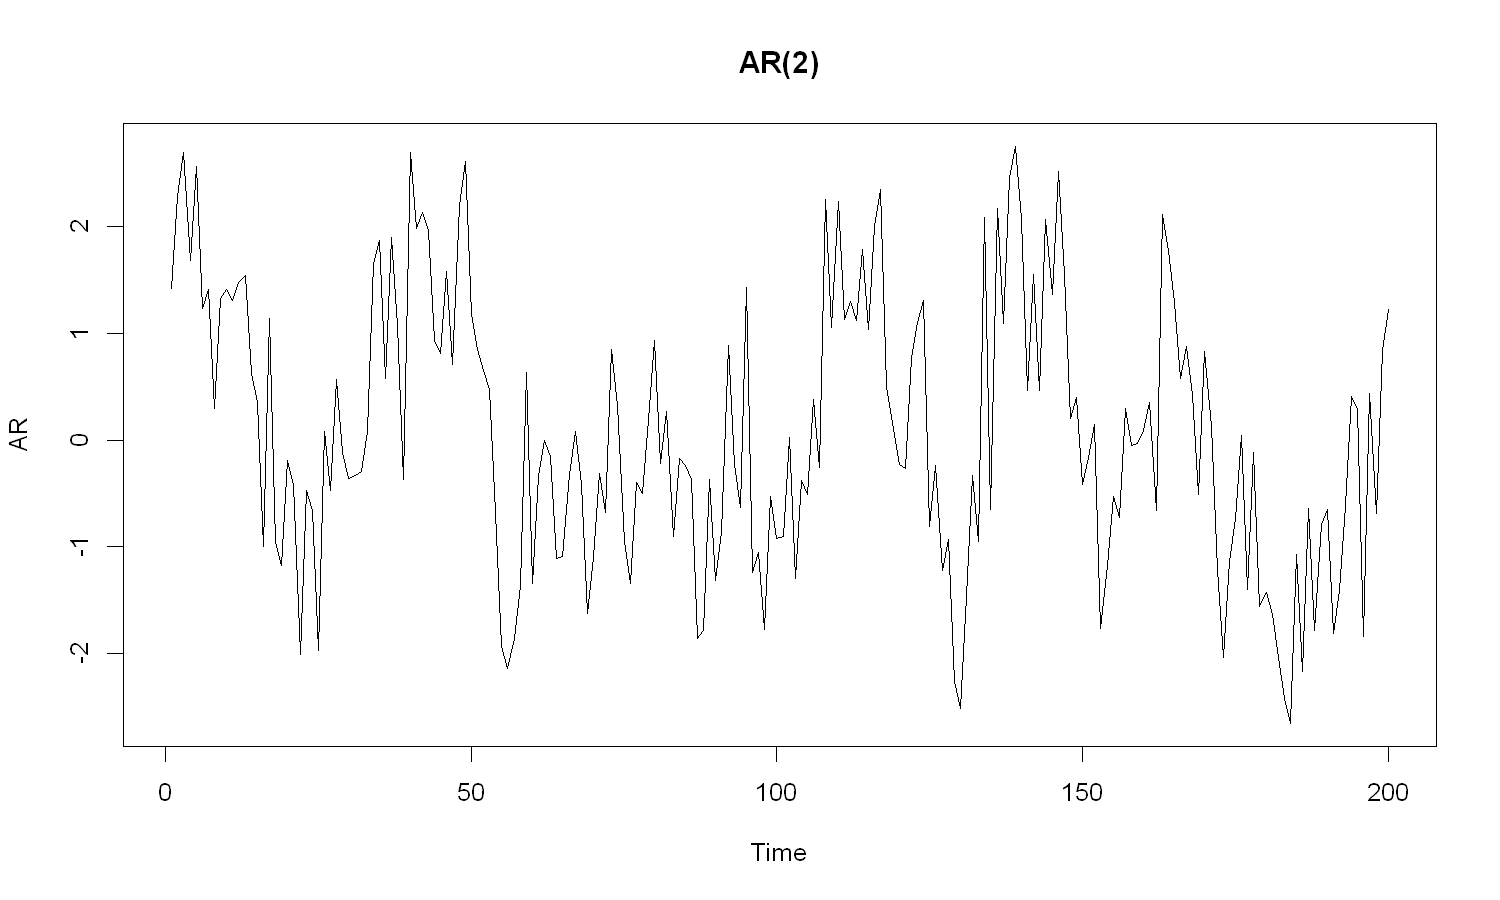

In [29]:
# Generate and plot an AR(2) with parameters 1.5 and -.75
AR <- arima.sim(model = list(order = c(2, 0, 0), ar = c(0.5, 0.3)), n = 200)
plot(AR, main = "AR(2)")